# Reaction Time Model

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/aarohi_verma/Downloads/final_project/ICCS2026_Final_Project


### Objective

This notebook models participant reaction times using the subjective value difference between the immediate and delayed options. The model is fitted using the processed training data and evaluated by comparing predicted and observed reaction times.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATA_DIR
from src.data_loader import load_all_participants
from src.preprocessing import get_split, combine_participants
from src.discounting import add_subjective_values

### 1. Load Preprocessed Data

The participant data are loaded and combined into a single training dataset for reaction time modelling.

In [7]:
participants = load_all_participants(DATA_DIR)

In [8]:
train = get_split(participants, "train")

combined_train = combine_participants(train)

combined_train.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,participant
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,Sample1_07mpzgefw
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,Sample1_07mpzgefw
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,Sample1_07mpzgefw
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,Sample1_07mpzgefw
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,Sample1_07mpzgefw


### 2. Compute Subjective Values

Subjective values are calculated using the hyperbolic discounting model. These values provide the explanatory variable used to model reaction times.

In [10]:
combined_train = add_subjective_values(
    combined_train,
    k=0.01
)

combined_train.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,participant,SV_immediate,SV_delayed,value_difference
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,Sample1_07mpzgefw,1.79,1.785714,-0.004286
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,Sample1_07mpzgefw,9.99,7.692308,-2.297692
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,Sample1_07mpzgefw,7.33,2.150538,-5.179462
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,Sample1_07mpzgefw,0.46,17.857143,17.397143
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,Sample1_07mpzgefw,0.91,26.315789,25.405789


### 3. Explore Reaction Times

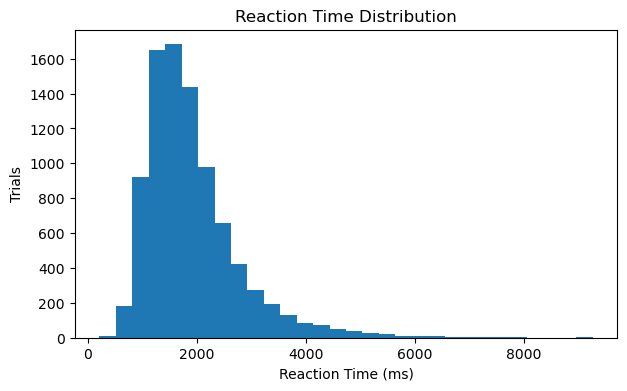

In [11]:
plt.figure(figsize=(7,4))
plt.hist(
    combined_train["RT"].dropna(),
    bins=30
)
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Trials")
plt.title("Reaction Time Distribution")
plt.show()

The reaction time distribution shows the range of participant response times and provides an initial understanding of the behavioural data before model fitting.

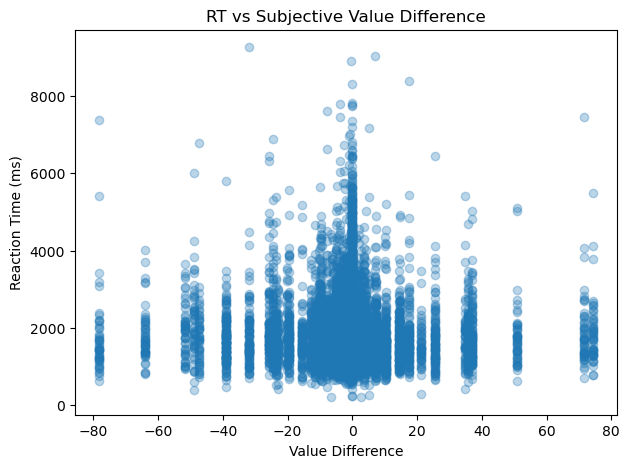

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(
    combined_train["value_difference"],
    combined_train["RT"],
    alpha=0.3
)
plt.xlabel("Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("RT vs Subjective Value Difference")
plt.show()

This figure illustrates the relationship between subjective value difference and reaction time. Larger value differences are generally expected to correspond to faster decisions.

In [13]:
from src.rt_models import fit_rt_model

### 4. Fit the Reaction Time Model

The reaction time model is fitted using nonlinear optimization to estimate the model parameters.

In [36]:
rt_result = fit_rt_model(combined_train)

In [37]:
a, b, c = rt_result.x

print(f"Estimated parameter a: {a:.4f}")
print(f"Estimated parameter b: {b:.4f}")
print(f"Estimated parameter c: {c:.4f}")

Estimated parameter a: 1801.1879
Estimated parameter b: 100.0000
Estimated parameter c: 0.2724


In [23]:
from src.rt_models import add_predicted_rt

### 5. Predict Reaction Times

The fitted parameters are used to generate predicted reaction times for each trial in the dataset.

In [24]:
a, b, c = rt_result.x
predictions = add_predicted_rt(
    combined_train,
    a,
    b,
    c
)
predictions.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,participant,SV_immediate,SV_delayed,value_difference,predicted_RT
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,Sample1_07mpzgefw,1.79,1.785714,-0.004286,2162.624540
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,Sample1_07mpzgefw,9.99,7.692308,-2.297692,1840.097141
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,Sample1_07mpzgefw,7.33,2.150538,-5.179462,1819.530247
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,Sample1_07mpzgefw,0.46,17.857143,17.397143,1806.847310
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,Sample1_07mpzgefw,0.91,26.315789,25.405789,1805.082207


In [38]:
valid = predictions.dropna(subset=["RT"])

print(f"Number of observations used for evaluation: {len(valid)}")

Number of observations used for evaluation: 8886


### 6. Evaluate Model Performance

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        valid["RT"],
        valid["predicted_RT"]
    )
)

print("RMSE:", rmse)

RMSE: 882.8226767453597


The Root Mean Squared Error (RMSE) provides a summary measure of prediction accuracy. Lower values indicate that the predicted reaction times are closer to the observed reaction times.

In [39]:
print(f"Number of evaluated trials: {len(valid)}")

Number of evaluated trials: 8886


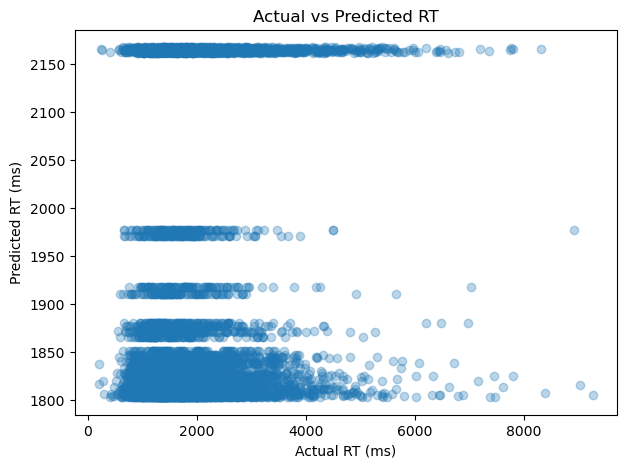

In [33]:
plt.figure(figsize=(7,5))

plt.scatter(
    valid["RT"],
    valid["predicted_RT"],
    alpha=0.3
)

plt.xlabel("Actual RT (ms)")
plt.ylabel("Predicted RT (ms)")
plt.title("Actual vs Predicted RT")
plt.show()

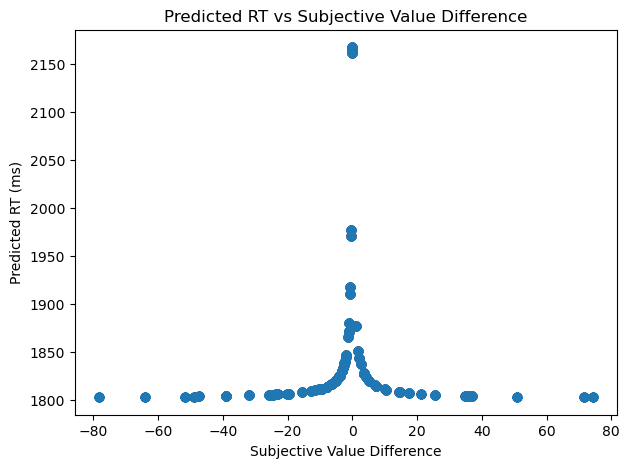

In [34]:
plt.figure(figsize=(7,5))

plt.scatter(
    valid["value_difference"],
    valid["predicted_RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Predicted RT (ms)")
plt.title("Predicted RT vs Subjective Value Difference")

plt.show()